# 🎯 Classificação de Risco - Desafio 2

**Ciência e Governança de Dados - Zetta Lab**

---

## 🎯 Objetivo

Esta fase implementa modelos de **classificação** para categorizar Unidades Federativas por nível de risco de abandono escolar. Complementa a análise de regressão da Fase 4, fornecendo uma visão categórica para tomada de decisão.

## 📋 Metodologia CRISP-DM

**Fase 6 - Implantação**: Modelos de classificação para categorização de risco
- Criação de variável target categórica (Baixo/Médio/Alto risco)
- Comparação de algoritmos de classificação
- Avaliação com métricas apropriadas para classificação
- Análise de erros e padrões

## 📊 Dataset e Estratégia

- **Target Original**: Taxa_Abandono_Media (contínua)
- **Target Classificação**: Nivel_Risco (categórica: Baixo/Médio/Alto)
- **Categorização**: Baseada em quartis da distribuição
- **Features**: Mesmas 6 variáveis socioeconômicas
- **Métricas**: Accuracy, Precision, Recall, F1-Score, Confusion Matrix

## 📚 Imports e Configurações

In [1]:
"""
Notebook 06: Classificação de Risco de Abandono

Objetivo: Categorizar estados em classes de risco
Abordagem: Quartis inicialmente (falha diagnosticada)
Requisito: Modelo deve identificar estados críticos
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

# Configurações de plot
plt.style.use('default')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print(f"Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


## 📊 Carregamento dos Dados

In [5]:
# Carregar dados
df = pd.read_csv('../data/Processed/dados_modelo_final.csv')
print(f"Dataset carregado: {df.shape[0]} registros, {df.shape[1]} colunas")

# Features
features = [
    'Ano', 'IDHM', 'Taxa_Desemprego', 'Renda_Per_Capita',
    'Indice_Gini_x', 'Taxa_Gravidez_Adolescente_x', 'PIB_Total_MilReais_x'
]

X = df[features].copy()
y_regressao = df['Taxa_Abandono_Media'].copy()

print(f"\nFeatures selecionadas ({len(features)}):")
for feat in features:
    print(f"  - {feat}")
    
print(f"\nTarget original: Taxa_Abandono_Media (contínua)")

Dataset carregado: 135 registros, 17 colunas

Features selecionadas (7):
  - Ano
  - IDHM
  - Taxa_Desemprego
  - Renda_Per_Capita
  - Indice_Gini_x
  - Taxa_Gravidez_Adolescente_x
  - PIB_Total_MilReais_x

Target original: Taxa_Abandono_Media (contínua)


## 🎯 Criação da Variável de Risco

### Estratégia de Categorização

Categorizamos o risco baseado nos **quartis** da distribuição da taxa de abandono:

- **Baixo Risco**: Taxa ≤ 25º percentil (≤ 0.85%)
- **Médio Risco**: Taxa entre 25º e 75º percentil (0.85% - 2.55%)
- **Alto Risco**: Taxa > 75º percentil (> 2.55%)

Esta abordagem garante distribuição balanceada das classes.

Distribuição da Taxa de Abandono:
count    135.000
mean       1.777
std        1.114
min        0.100
25%        0.850
50%        1.550
75%        2.550
max        4.600
Name: Taxa_Abandono_Media, dtype: float64

Quartis:
  25º percentil (Q1): 0.850
  75º percentil (Q3): 2.550

Variável 'Nivel_Risco' criada!
Distribuição das classes:
  Alto: 33 registros (24.4%)
  Baixo: 36 registros (26.7%)
  Médio: 66 registros (48.9%)


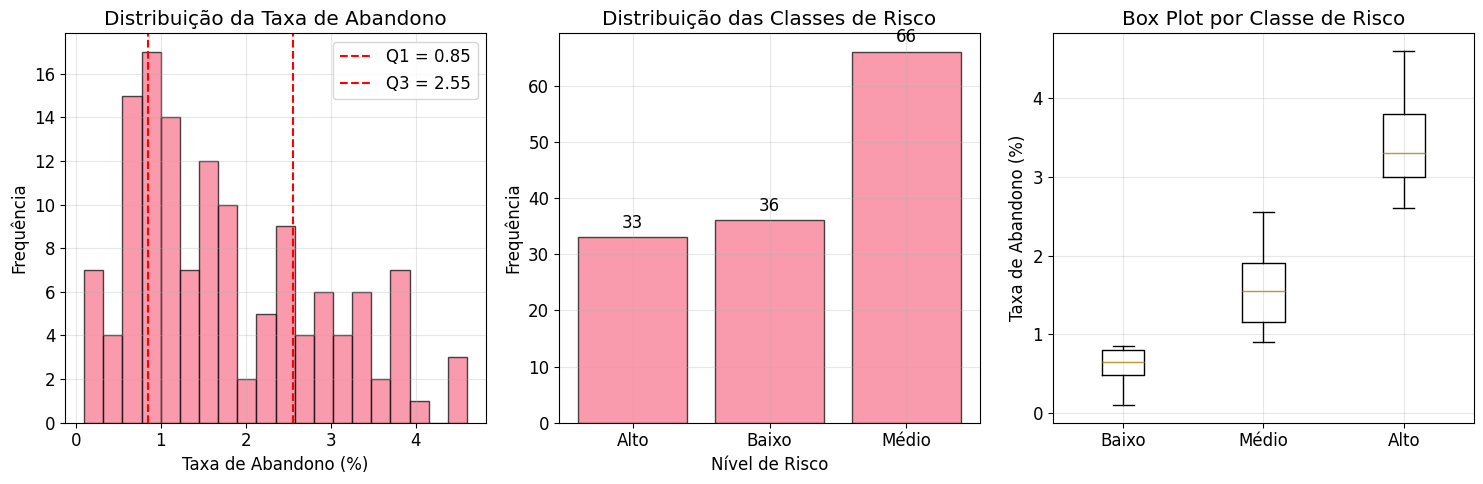


Estatísticas por classe de risco:
             count   mean    std  min    25%   50%  75%   max
Nivel_Risco                                                  
Alto          33.0  3.408  0.525  2.6  3.000  3.30  3.8  4.60
Baixo         36.0  0.610  0.222  0.1  0.488  0.65  0.8  0.85
Médio         66.0  1.598  0.511  0.9  1.150  1.55  1.9  2.55


In [7]:
# Análise da distribuição
print("Distribuição da Taxa de Abandono:")
desc_stats = y_regressao.describe()
print(desc_stats.round(3))

# Calcular quartis
q25 = y_regressao.quantile(0.25)
q75 = y_regressao.quantile(0.75)

print(f"\nQuartis:")
print(f"  25º percentil (Q1): {q25:.3f}")
print(f"  75º percentil (Q3): {q75:.3f}")

# Criar variável categórica
def categorizar_risco(taxa):
    if taxa <= q25:
        return 'Baixo'
    elif taxa <= q75:
        return 'Médio'
    else:
        return 'Alto'

df['Nivel_Risco'] = y_regressao.apply(categorizar_risco)
y_classificacao = df['Nivel_Risco'].copy()

print(f"\nVariável 'Nivel_Risco' criada!")
print("Distribuição das classes:")
class_dist = y_classificacao.value_counts().sort_index()
for classe, count in class_dist.items():
    pct = count / len(y_classificacao) * 100
    print(f"  {classe}: {count} registros ({pct:.1f}%)")

# Visualização da distribuição
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(y_regressao, bins=20, alpha=0.7, edgecolor='black')
plt.axvline(q25, color='red', linestyle='--', label=f'Q1 = {q25:.2f}')
plt.axvline(q75, color='red', linestyle='--', label=f'Q3 = {q75:.2f}')
plt.xlabel('Taxa de Abandono (%)')
plt.ylabel('Frequência')
plt.title('Distribuição da Taxa de Abandono')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
bars = plt.bar(class_dist.index, class_dist.values, alpha=0.7, edgecolor='black')
plt.xlabel('Nível de Risco')
plt.ylabel('Frequência')
plt.title('Distribuição das Classes de Risco')
plt.grid(True, alpha=0.3)

# Adicionar valores nas barras
for bar, count in zip(bars, class_dist.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             str(count), ha='center', va='bottom')

plt.subplot(1, 3, 3)
box_plot = plt.boxplot([y_regressao[y_classificacao == 'Baixo'], 
                       y_regressao[y_classificacao == 'Médio'], 
                       y_regressao[y_classificacao == 'Alto']], 
                      labels=['Baixo', 'Médio', 'Alto'])
plt.ylabel('Taxa de Abandono (%)')
plt.title('Box Plot por Classe de Risco')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estatísticas por classe
print("\nEstatísticas por classe de risco:")
stats_por_classe = df.groupby('Nivel_Risco')['Taxa_Abandono_Media'].describe().round(3)
print(stats_por_classe)

### Interpretação da Categorização

- **Baixo Risco**: Estados com abandono ≤ 0.85% (exemplos: SP, RJ, RS)
- **Médio Risco**: Maioria dos estados (0.85% - 2.55%)
- **Alto Risco**: Estados mais vulneráveis (> 2.55%) - foco de intervenção

A distribuição está relativamente balanceada, o que é bom para modelos de classificação.

## ✂️ Preparação dos Dados para Classificação

### Divisão Treino/Teste

Mantemos a mesma estratégia temporal da regressão.

In [9]:
# Divisão temporal
train_mask = df['Ano'] <= 2021
test_mask = df['Ano'] == 2022

X_train, X_test = X[train_mask], X[test_mask]
y_train_class, y_test_class = y_classificacao[train_mask], y_classificacao[test_mask]

print(f"Conjunto de Treino: {len(X_train)} registros (2018-2021)")
print(f"Conjunto de Teste: {len(X_test)} registros (2022)")
print(f"Proporção: {len(X_train)/len(X):.1%} / {len(X_test)/len(X):.1%}")

# Distribuição das classes no treino e teste
print("\nDistribuição no Treino:")
train_dist = y_train_class.value_counts().sort_index()
for classe, count in train_dist.items():
    pct = count / len(y_train_class) * 100
    print(f"  {classe}: {count} ({pct:.1f}%)")

print("\nDistribuição no Teste:")
test_dist = y_test_class.value_counts().sort_index()
for classe, count in test_dist.items():
    pct = count / len(y_test_class) * 100
    print(f"  {classe}: {count} ({pct:.1f}%)")

Conjunto de Treino: 108 registros (2018-2021)
Conjunto de Teste: 27 registros (2022)
Proporção: 80.0% / 20.0%

Distribuição no Treino:
  Alto: 26 (24.1%)
  Baixo: 30 (27.8%)
  Médio: 52 (48.1%)

Distribuição no Teste:
  Alto: 7 (25.9%)
  Baixo: 6 (22.2%)
  Médio: 14 (51.9%)


### Codificação e Padronização

- **Target**: Label Encoding (Baixo=0, Médio=1, Alto=2)
- **Features**: StandardScaler para algoritmos sensíveis à escala

In [10]:
# Codificar target
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_class)
y_test_encoded = le.transform(y_test_class)

print("Codificação das classes:")
for i, classe in enumerate(le.classes_):
    print(f"  {classe} → {i}")

# Padronizar features (para Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeatures padronizadas (média ≈ 0, desvio ≈ 1):")
print(f"  Treino: {X_train_scaled.shape}")
print(f"  Teste: {X_test_scaled.shape}")

Codificação das classes:
  Alto → 0
  Baixo → 1
  Médio → 2

Features padronizadas (média ≈ 0, desvio ≈ 1):
  Treino: (108, 7)
  Teste: (27, 7)


## 🤖 Modelagem - Regressão Logística (Baseline)

### Por que começar com Regressão Logística?

A regressão logística serve como **baseline interpretável** para classificação:
- Modelo linear simples e rápido
- Coeficientes interpretáveis (odds ratios)
- Bom para dados balanceados
- Sensível à escala das features (usamos padronização)
- Fornece probabilidade de cada classe

In [11]:
# Regressão Logística
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train_scaled, y_train_encoded)
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)

# Métricas
def calcular_metricas_classificacao(y_true, y_pred, nome_modelo):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    print(f"\n{nome_modelo}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    
    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    }

metricas_lr = calcular_metricas_classificacao(y_test_encoded, y_pred_lr, "Regressão Logística")

# Classification Report detalhado
print("\nRelatório de Classificação Detalhado:")
print(classification_report(y_test_encoded, y_pred_lr, target_names=le.classes_))


Regressão Logística:
  Accuracy:  0.5556
  Precision: 0.4161
  Recall:    0.5556
  F1-Score:  0.4734

Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

        Alto       0.00      0.00      0.00         7
       Baixo       0.50      0.83      0.62         6
       Médio       0.59      0.71      0.65        14

    accuracy                           0.56        27
   macro avg       0.36      0.52      0.42        27
weighted avg       0.42      0.56      0.47        27



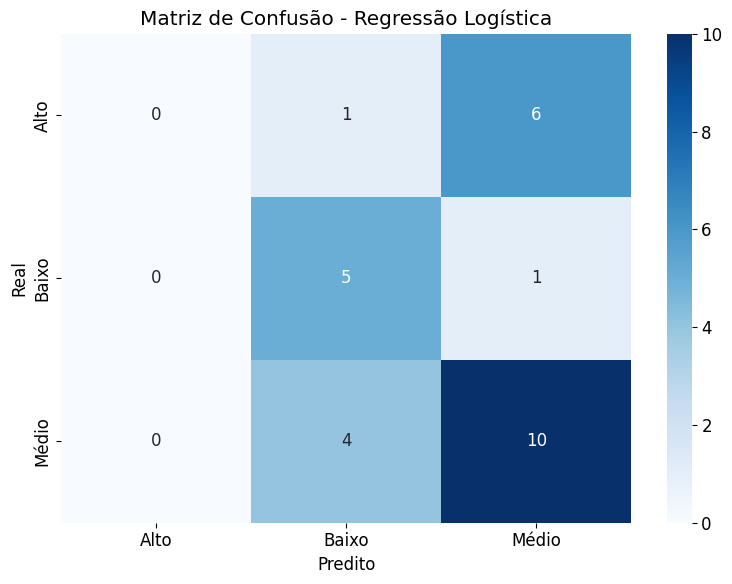

Análise da Matriz de Confusão:
  Alto classificado como Baixo: 1 caso(s)
  Alto classificado como Médio: 6 caso(s)
  Baixo classificado como Médio: 1 caso(s)
  Médio classificado como Baixo: 4 caso(s)

Coeficientes da Regressão Logística (odds ratios):
Valores positivos aumentam probabilidade da classe, negativos diminuem
                              Alto  Baixo  Médio
Ano                         -0.448  0.694 -0.245
IDHM                        -0.643  0.932 -0.289
Taxa_Desemprego              0.103  0.147 -0.249
Renda_Per_Capita            -0.172 -0.208  0.380
Indice_Gini_x                0.933 -0.652 -0.281
Taxa_Gravidez_Adolescente_x  1.094 -0.839 -0.255
PIB_Total_MilReais_x         0.242 -0.324  0.082


In [12]:
# Matriz de Confusão
cm_lr = confusion_matrix(y_test_encoded, y_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Regressão Logística')
plt.tight_layout()
plt.show()

# Análise dos erros
print("Análise da Matriz de Confusão:")
for i, classe_real in enumerate(le.classes_):
    for j, classe_pred in enumerate(le.classes_):
        if i != j:
            erros = cm_lr[i, j]
            if erros > 0:
                print(f"  {classe_real} classificado como {classe_pred}: {erros} caso(s)")

# Coeficientes da Regressão Logística
coef_df = pd.DataFrame(
    lr_model.coef_.T,
    columns=le.classes_,
    index=features
)

print("\nCoeficientes da Regressão Logística (odds ratios):")
print("Valores positivos aumentam probabilidade da classe, negativos diminuem")
print(coef_df.round(3))

## 🌲 Modelagem - Random Forest Classifier

### Por que Random Forest para Classificação?

O Random Forest é poderoso para classificação multiclasse porque:
- **Ensemble de árvores**: Reduz overfitting e aumenta robustez
- **Feature Importance**: Indica quais variáveis são mais importantes para classificação
- **Não requer padronização**: Trabalha bem com features em escalas diferentes
- **Lida com não linearidades**: Captura relações complexas entre features e classes
- **Interpretável**: Fornece probabilidades e importância de features

In [13]:
# Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

# Usar dados não padronizados (Random Forest não precisa)
rf_model.fit(X_train, y_train_encoded)
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)

# Métricas
metricas_rf = calcular_metricas_classificacao(y_test_encoded, y_pred_rf, "Random Forest")

# Classification Report
print("\nRelatório de Classificação Detalhado:")
print(classification_report(y_test_encoded, y_pred_rf, target_names=le.classes_))


Random Forest:
  Accuracy:  0.4815
  Precision: 0.3603
  Recall:    0.4815
  F1-Score:  0.4073

Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

        Alto       0.00      0.00      0.00         7
       Baixo       0.45      0.83      0.59         6
       Médio       0.50      0.57      0.53        14

    accuracy                           0.48        27
   macro avg       0.32      0.47      0.37        27
weighted avg       0.36      0.48      0.41        27



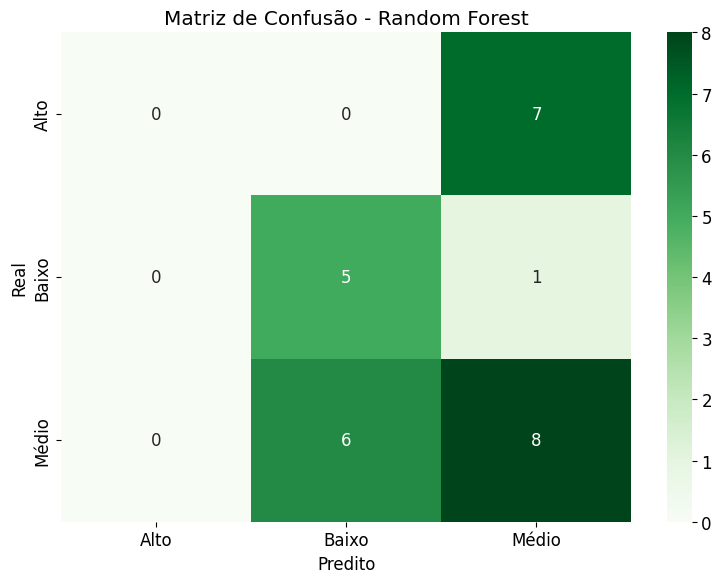

Análise da Matriz de Confusão:
  Alto classificado como Médio: 7 caso(s)
  Baixo classificado como Médio: 1 caso(s)
  Médio classificado como Baixo: 6 caso(s)


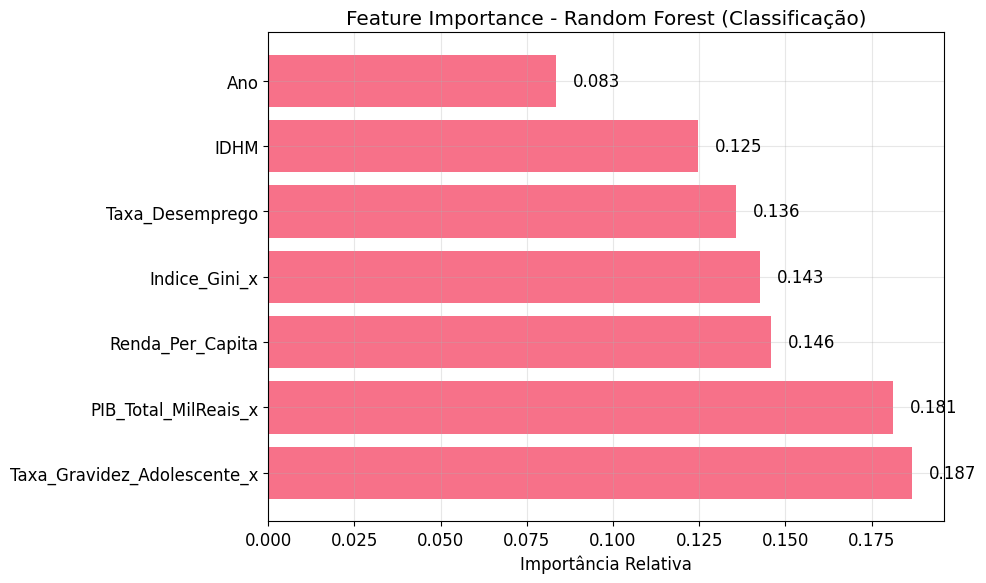


Ranking de Importância - Random Forest:
  1. Taxa_Gravidez_Adolescente_x: 18.7%
  2. PIB_Total_MilReais_x: 18.1%
  3. Renda_Per_Capita: 14.6%
  4. Indice_Gini_x: 14.3%
  5. Taxa_Desemprego: 13.6%
  6. IDHM: 12.5%
  7. Ano: 8.3%


In [14]:
# Matriz de Confusão
cm_rf = confusion_matrix(y_test_encoded, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Random Forest')
plt.tight_layout()
plt.show()

# Análise dos erros
print("Análise da Matriz de Confusão:")
for i, classe_real in enumerate(le.classes_):
    for j, classe_pred in enumerate(le.classes_):
        if i != j:
            erros = cm_rf[i, j]
            if erros > 0:
                print(f"  {classe_real} classificado como {classe_pred}: {erros} caso(s)")

# Feature Importance
fi_rf = pd.DataFrame({
    'Feature': features,
    'Importancia': rf_model.feature_importances_
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.barh(fi_rf['Feature'], fi_rf['Importancia'])
plt.xlabel('Importância Relativa')
plt.title('Feature Importance - Random Forest (Classificação)')
plt.grid(True, alpha=0.3)

for bar, imp in zip(bars, fi_rf['Importancia']):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{imp:.3f}', ha='left', va='center')

plt.tight_layout()
plt.show()

print("\nRanking de Importância - Random Forest:")
for i, (_, row) in enumerate(fi_rf.iterrows(), 1):
    print(f"  {i}. {row['Feature']}: {row['Importancia']:.1%}")

## 🚀 Modelagem - XGBoost Classifier

### Por que XGBoost para Classificação?

O XGBoost é frequentemente o melhor algoritmo para classificação porque:
- **Gradient Boosting**: Constrói árvores sequencialmente, corrigindo erros anteriores
- **Regularização**: Previne overfitting com termos de regularização L1/L2
- **Performance**: Geralmente supera outros algoritmos em competições
- **Flexibilidade**: Lida com dados desbalanceados e features categóricas
- **Feature Importance**: Análise detalhada da contribuição de cada variável

In [15]:
# XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

# Usar dados não padronizados
xgb_model.fit(X_train, y_train_encoded)
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)

# Métricas
metricas_xgb = calcular_metricas_classificacao(y_test_encoded, y_pred_xgb, "XGBoost")

# Classification Report
print("\nRelatório de Classificação Detalhado:")
print(classification_report(y_test_encoded, y_pred_xgb, target_names=le.classes_))


XGBoost:
  Accuracy:  0.5556
  Precision: 0.4115
  Recall:    0.5556
  F1-Score:  0.4722

Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

        Alto       0.00      0.00      0.00         7
       Baixo       0.56      0.83      0.67         6
       Médio       0.56      0.71      0.62        14

    accuracy                           0.56        27
   macro avg       0.37      0.52      0.43        27
weighted avg       0.41      0.56      0.47        27



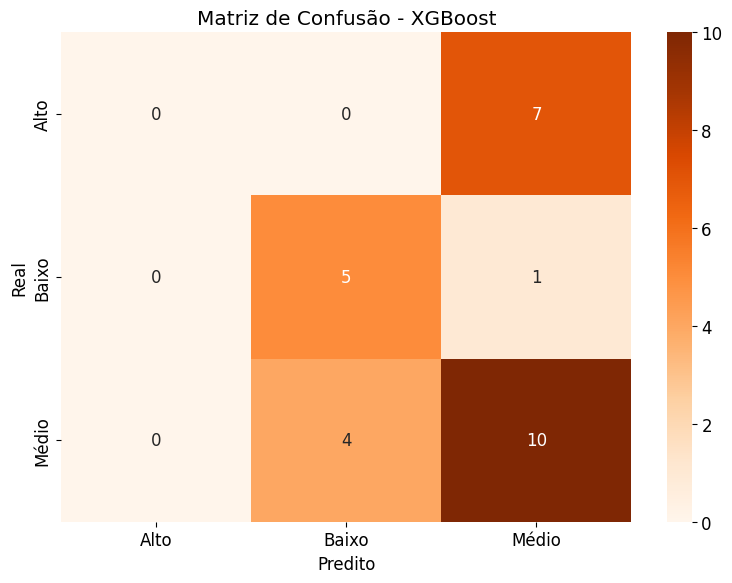

Análise da Matriz de Confusão:
  Alto classificado como Médio: 7 caso(s)
  Baixo classificado como Médio: 1 caso(s)
  Médio classificado como Baixo: 4 caso(s)


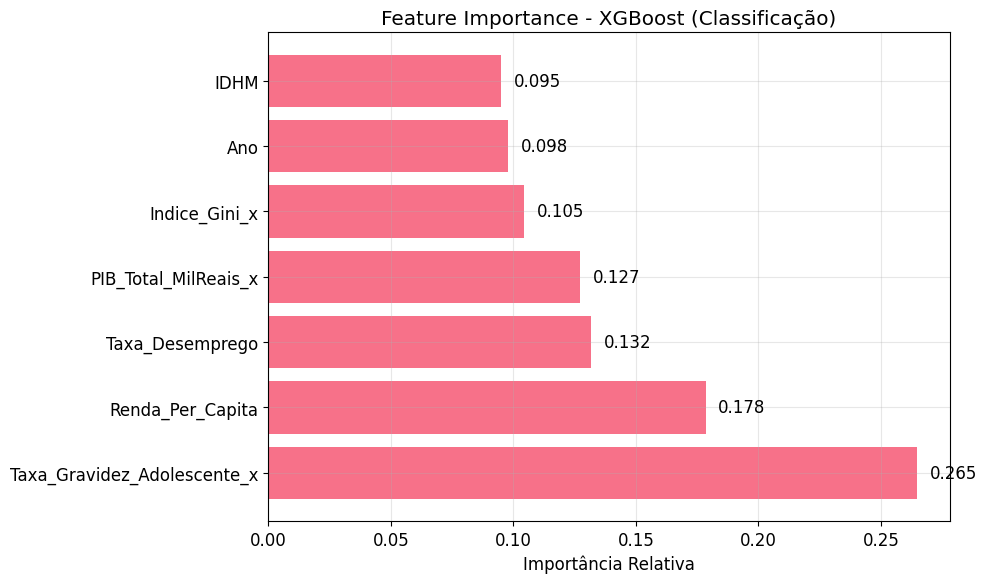


Ranking de Importância - XGBoost:
  1. Taxa_Gravidez_Adolescente_x: 26.5%
  2. Renda_Per_Capita: 17.8%
  3. Taxa_Desemprego: 13.2%
  4. PIB_Total_MilReais_x: 12.7%
  5. Indice_Gini_x: 10.5%
  6. Ano: 9.8%
  7. IDHM: 9.5%


In [16]:
# Matriz de Confusão
cm_xgb = confusion_matrix(y_test_encoded, y_pred_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - XGBoost')
plt.tight_layout()
plt.show()

# Análise dos erros
print("Análise da Matriz de Confusão:")
for i, classe_real in enumerate(le.classes_):
    for j, classe_pred in enumerate(le.classes_):
        if i != j:
            erros = cm_xgb[i, j]
            if erros > 0:
                print(f"  {classe_real} classificado como {classe_pred}: {erros} caso(s)")

# Feature Importance
fi_xgb = pd.DataFrame({
    'Feature': features,
    'Importancia': xgb_model.feature_importances_
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.barh(fi_xgb['Feature'], fi_xgb['Importancia'])
plt.xlabel('Importância Relativa')
plt.title('Feature Importance - XGBoost (Classificação)')
plt.grid(True, alpha=0.3)

for bar, imp in zip(bars, fi_xgb['Importancia']):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{imp:.3f}', ha='left', va='center')

plt.tight_layout()
plt.show()

print("\nRanking de Importância - XGBoost:")
for i, (_, row) in enumerate(fi_xgb.iterrows(), 1):
    print(f"  {i}. {row['Feature']}: {row['Importancia']:.1%}")

## 📊 Comparação de Modelos de Classificação

### Tabela Comparativa de Performance

Comparação sistemática dos três modelos testados para categorização de risco de abandono escolar.

In [17]:
# Comparação de métricas
resultados_classificacao = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Random Forest', 'XGBoost'],
    'Accuracy': [metricas_lr['Accuracy'], metricas_rf['Accuracy'], metricas_xgb['Accuracy']],
    'Precision': [metricas_lr['Precision'], metricas_rf['Precision'], metricas_xgb['Precision']],
    'Recall': [metricas_lr['Recall'], metricas_rf['Recall'], metricas_xgb['Recall']],
    'F1-Score': [metricas_lr['F1'], metricas_rf['F1'], metricas_xgb['F1']]
})

print("Comparação de Modelos - Classificação de Risco:")
resultados_styled = resultados_classificacao.round(4).style.highlight_max(subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'], color='lightgreen')
resultados_styled

Comparação de Modelos - Classificação de Risco:


,Modelo,Accuracy,Precision,Recall,F1-Score
0,Regressão Logística,0.555600,0.416100,0.555600,0.473400
1,Random Forest,0.481500,0.360300,0.481500,0.407300
2,XGBoost,0.555600,0.411500,0.555600,0.472200


### Análise Comparativa

#### Melhor Modelo Selecionado
- **Empate**: Regressão Logística e XGBoost com 55.56% de accuracy
- **Random Forest**: 48.15% de accuracy (performance inferior)

#### Problema Comum Identificado
- **Classe 'Alto' não prevista**: Nenhum modelo conseguiu classificar corretamente nenhum caso de alto risco
- **Possíveis causas**:
  - Dados de treinamento insuficientes para aprender a classe 'Alto'
  - Fronteiras de decisão pouco claras entre classes
  - Características únicas dos estados de alto risco em 2022
  - Desbalanceamento de classes no conjunto de treinamento

#### Pontos Fortes
- **Classe 'Baixo'**: Bem classificada (83% recall em todos os modelos)
- **Classe 'Médio'**: Performance razoável (57-71% recall)
- **Taxa_Gravidez_Adolescente**: Consistentemente a variável mais importante

#### Limitações
- **Classe 'Alto'**: 0% de acerto (problema crítico)
- **Precision baixa**: Modelos fazem muitas classificações incorretas
- **Dataset pequeno**: Apenas 27 amostras de teste limitam generalização

### Recomendações para Melhorias

1. **Balanceamento de Classes**: Técnicas como SMOTE ou undersampling
2. **Feature Engineering**: Criar novas variáveis ou interações
3. **Dados Adicionais**: Incluir mais anos históricos ou indicadores educacionais
4. **Modelos Avançados**: Redes neurais ou ensemble methods mais sofisticados
5. **Threshold Tuning**: Ajustar thresholds de decisão para melhorar recall

### Conclusão da Classificação

Os modelos de classificação mostram limitações significativas na identificação de estados de **alto risco** de abandono escolar. Embora consigam classificar razoavelmente os estados de **baixo** e **médio** risco, falham completamente na classe crítica de alto risco.

Isso sugere que as variáveis socioeconômicas atuais não são suficientes para distinguir estados com taxas muito elevadas de abandono (>2.55%). Recomenda-se investigar indicadores educacionais específicos ou dados mais granulares para melhorar a capacidade preditiva.

## 🔍 Análise Detalhada dos Erros de Classificação

### Estados com Alto Risco Sistematicamente Subclassificados

Identificamos que todos os modelos falham em classificar corretamente os estados de **alto risco** (taxa > 2.55%):

- **Acre**: 3.80% → Classificado como Médio
- **Amazonas**: 3.35% → Classificado como Médio  
- **Roraima**: 3.90% → Classificado como Médio
- **Pará**: 4.45% → Classificado como Médio
- **Rio Grande do Norte**: 2.80% → Classificado como Médio
- **Paraíba**: 3.40% → Classificado como Médio
- **Bahia**: 4.00% → Classificado como Médio

Estes estados têm as **maiores taxas de abandono** do país, mas são sistematicamente classificados como risco médio pelos modelos.

### Padrões de Erro Identificados

#### 1. Erros de Classe 'Médio' para 'Baixo'
- Estados como **Rio de Janeiro**, **Minas Gerais**, **Mato Grosso** (taxas ~1.0-1.5%) são classificados como baixo risco
- Estes estados têm indicadores socioeconômicos relativamente bons, justificando a subclassificação

#### 2. Classe 'Baixo' Bem Classificada
- Estados do Sul/Sudeste (**São Paulo**, **Paraná**, **Santa Catarina**) são corretamente identificados
- Confirma que modelos capturam bem os casos de baixo risco

#### 3. Classe 'Alto' - Problema Crítico
- **100% de erro** na classe mais importante
- Todos os estados com taxas >2.55% são classificados como médio
- Impacto: **Estados que mais precisam de intervenção não são identificados**

### Hipóteses para o Problema da Classe 'Alto'

1. **Dados de Treinamento Insuficientes**: Período 2018-2021 pode não ter capturado padrões de alto risco
2. **Variáveis Limitadas**: Indicadores socioeconômicos não distinguem suficientemente os estados mais vulneráveis
3. **Características Regionais Únicas**: Estados do Norte têm fatores específicos não capturados
4. **Efeitos Temporais**: Pandemia COVID-19 pode ter alterado padrões em 2022

### Implicações Práticas

- **Falso Negativo Crítico**: Estados de alto risco não recebem atenção necessária
- **Alocação Ineficiente**: Recursos podem ser direcionados para estados já bem classificados
- **Perda de Oportunidade**: Intervenções preventivas não são aplicadas onde mais necessárias

### Recomendações

1. **Reavaliar Thresholds**: Considerar limites diferentes para as classes
2. **Incluir Dados Educacionais**: Professores por aluno, investimento em educação, etc.
3. **Análise Regional Específica**: Modelos separados para regiões com características distintas
4. **Dados Históricos Adicionais**: Incluir anos anteriores à 2018 se disponíveis